# Compare Live Segmentation Methods

Compare three live mask paths on the same saved webcam frames:
- current ROI hair segmentation
- MediaPipe Selfie Segmentation head-region mask
- hybrid ROI + Selfie mask

This is the right notebook to judge whether Selfie Segmentation gives us better live stability support.

In [1]:
from pathlib import Path
import sys
import json
import math

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from app.core.face_analyzer import analyze_face_image
from app.core.live_support import evaluate_supported_live_range, summarize_live_mask_quality
from app.core.selfie_segmentation import (
    selfie_segmentation_available,
    predict_selfie_head_region_mask,
    predict_hybrid_live_hair_mask,
)
from app.core.hair_segmentation import predict_hair_mask_image_from_face_roi

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
LIVE_FRAME_DIR = PROJECT_ROOT / 'backend' / 'outputs' / 'live_segmentation_eval' / 'inputs'
OUTPUT_DIR = PROJECT_ROOT / 'backend' / 'outputs' / 'evaluations' / 'live_segmentation_compare'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.webp'}
image_paths = [path for path in sorted(LIVE_FRAME_DIR.glob('*')) if path.suffix.lower() in IMAGE_EXTS]

print('Live frame dir:', LIVE_FRAME_DIR)
print('Frame count:', len(image_paths))

Live frame dir: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\live_segmentation_eval\inputs
Frame count: 31


In [3]:
SELFIE_AVAILABLE = selfie_segmentation_available()
print('Selfie Segmentation available:', SELFIE_AVAILABLE)
if not SELFIE_AVAILABLE:
    print('This environment does not expose MediaPipe Selfie Segmentation; ROI-only comparison can still run, but selfie/hybrid masks will be skipped.')

Selfie Segmentation available: False
This environment does not expose MediaPipe Selfie Segmentation; ROI-only comparison can still run, but selfie/hybrid masks will be skipped.


In [4]:
rows = []
preview_payloads = []
for image_path in image_paths:
    image = Image.open(image_path).convert('RGB')
    analysis = analyze_face_image(image_path)
    support = evaluate_supported_live_range(image, analysis)

    roi_mask = predict_hair_mask_image_from_face_roi(image, analysis.face_bbox) if analysis.face_bbox is not None else None
    roi_quality = summarize_live_mask_quality(analysis, roi_mask)

    selfie_mask = None
    hybrid_mask = None
    selfie_quality = {
        'mask_quality_reason': 'unavailable',
        'mask_reliable': False,
        'mask_nonzero_ratio': 0.0,
    }
    hybrid_quality = {
        'mask_quality_reason': 'unavailable',
        'mask_reliable': False,
        'mask_nonzero_ratio': 0.0,
    }

    if SELFIE_AVAILABLE:
        selfie_mask = predict_selfie_head_region_mask(image, analysis.face_bbox)
        hybrid_mask = predict_hybrid_live_hair_mask(image, analysis.face_bbox)
        selfie_quality = summarize_live_mask_quality(analysis, selfie_mask)
        hybrid_quality = summarize_live_mask_quality(analysis, hybrid_mask)

    rows.append({
        'filename': image_path.name,
        'frame_supported': bool(support['frame_supported']),
        'support_reason': support['support_reason'],
        'roi_reason': roi_quality['mask_quality_reason'],
        'roi_reliable': bool(roi_quality['mask_reliable']),
        'roi_coverage': roi_quality['mask_nonzero_ratio'],
        'selfie_reason': selfie_quality['mask_quality_reason'],
        'selfie_reliable': bool(selfie_quality['mask_reliable']),
        'selfie_coverage': selfie_quality['mask_nonzero_ratio'],
        'hybrid_reason': hybrid_quality['mask_quality_reason'],
        'hybrid_reliable': bool(hybrid_quality['mask_reliable']),
        'hybrid_coverage': hybrid_quality['mask_nonzero_ratio'],
    })
    preview_payloads.append({
        'filename': image_path.name,
        'image': image,
        'roi_mask': roi_mask,
        'selfie_mask': selfie_mask,
        'hybrid_mask': hybrid_mask,
    })

results_df = pd.DataFrame(rows)
display(results_df.head())

,filename,frame_supported,support_reason,roi_reason,roi_reliable,roi_coverage,selfie_reason,selfie_reliable,selfie_coverage,hybrid_reason,hybrid_reliable,hybrid_coverage
0,live_frame_0001.png,True,supported,mask_too_narrow,False,0.007780,unavailable,False,0.0,unavailable,False,0.0
1,live_frame_0002.png,True,supported,reliable,True,0.015023,unavailable,False,0.0,unavailable,False,0.0
2,live_frame_0003.png,True,supported,reliable,True,0.012396,unavailable,False,0.0,unavailable,False,0.0
3,live_frame_0004.png,True,supported,mask_too_narrow,False,0.000010,unavailable,False,0.0,unavailable,False,0.0
4,live_frame_0005.png,True,supported,mask_too_narrow,False,0.005521,unavailable,False,0.0,unavailable,False,0.0


In [5]:
summary = {
    'frame_count': int(len(results_df)),
    'supported_frames': int(results_df['frame_supported'].sum()) if not results_df.empty else 0,
    'roi_reliable_count': int(results_df['roi_reliable'].sum()) if not results_df.empty else 0,
    'selfie_reliable_count': int(results_df['selfie_reliable'].sum()) if not results_df.empty else 0,
    'hybrid_reliable_count': int(results_df['hybrid_reliable'].sum()) if not results_df.empty else 0,
    'roi_reason_counts': {} if results_df.empty else results_df['roi_reason'].value_counts().to_dict(),
    'selfie_reason_counts': {} if results_df.empty else results_df['selfie_reason'].value_counts().to_dict(),
    'hybrid_reason_counts': {} if results_df.empty else results_df['hybrid_reason'].value_counts().to_dict(),
}
print(json.dumps(summary, indent=2))

summary_path = OUTPUT_DIR / 'live_segmentation_compare_summary.json'
results_path = OUTPUT_DIR / 'live_segmentation_compare_results.csv'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
results_df.to_csv(results_path, index=False)
print('Saved summary:', summary_path)
print('Saved results:', results_path)

{
  "frame_count": 31,
  "supported_frames": 31,
  "roi_reliable_count": 2,
  "selfie_reliable_count": 0,
  "hybrid_reliable_count": 0,
  "roi_reason_counts": {
    "mask_too_narrow": 26,
    "reliable": 2,
    "mask_off_center": 2,
    "empty": 1
  },
  "selfie_reason_counts": {
    "unavailable": 31
  },
  "hybrid_reason_counts": {
    "unavailable": 31
  }
}
Saved summary: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\evaluations\live_segmentation_compare\live_segmentation_compare_summary.json
Saved results: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\evaluations\live_segmentation_compare\live_segmentation_compare_results.csv


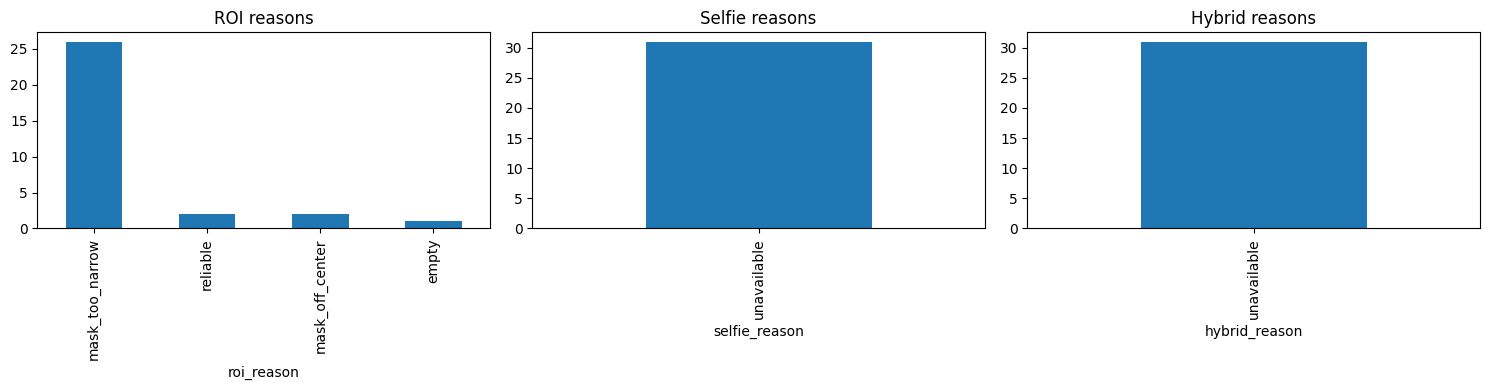

In [6]:
if not results_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    results_df['roi_reason'].value_counts().plot(kind='bar', ax=axes[0], title='ROI reasons')
    results_df['selfie_reason'].value_counts().plot(kind='bar', ax=axes[1], title='Selfie reasons')
    results_df['hybrid_reason'].value_counts().plot(kind='bar', ax=axes[2], title='Hybrid reasons')
    plt.tight_layout()
    plt.show()

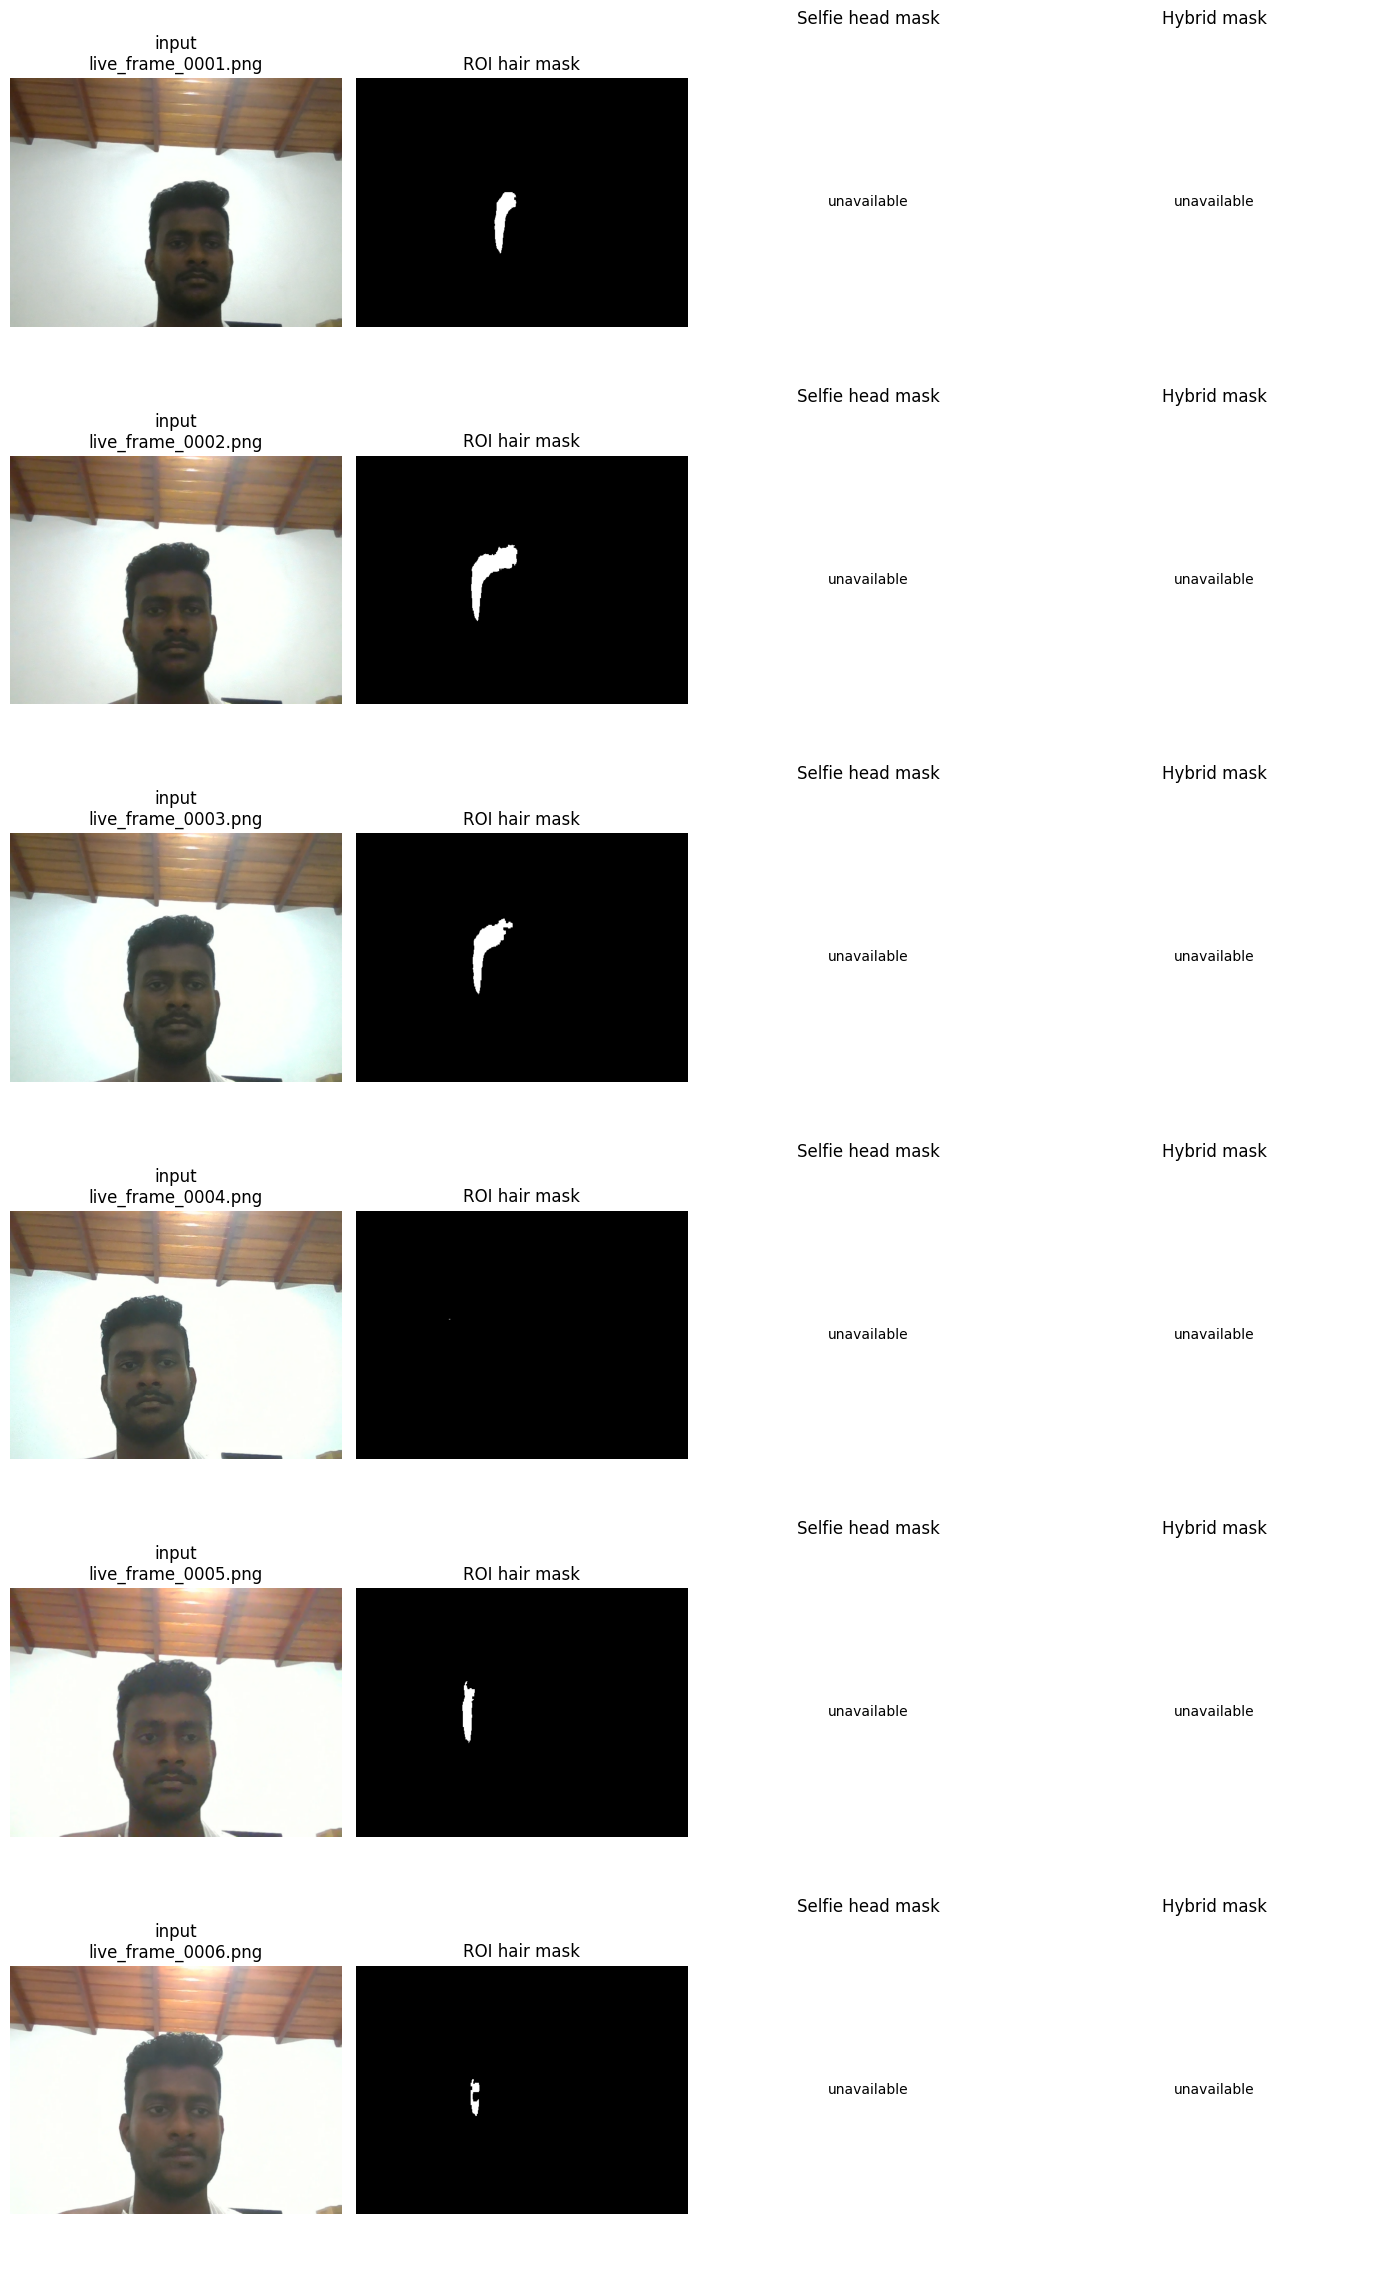

In [7]:
MAX_PREVIEW = 6
preview_rows = preview_payloads[:MAX_PREVIEW]
if preview_rows:
    fig, axes = plt.subplots(len(preview_rows), 4, figsize=(14, 3.8 * len(preview_rows)))
    if len(preview_rows) == 1:
        axes = [axes]

    for row_axes, payload in zip(axes, preview_rows):
        row_axes[0].imshow(payload['image'])
        row_axes[0].set_title(f"input\n{payload['filename']}")
        row_axes[1].imshow(payload['roi_mask'], cmap='gray')
        row_axes[1].set_title('ROI hair mask')

        if payload['selfie_mask'] is not None:
            row_axes[2].imshow(payload['selfie_mask'], cmap='gray')
            row_axes[2].set_title('Selfie head mask')
        else:
            row_axes[2].text(0.5, 0.5, 'unavailable', ha='center', va='center')
            row_axes[2].set_title('Selfie head mask')

        if payload['hybrid_mask'] is not None:
            row_axes[3].imshow(payload['hybrid_mask'], cmap='gray')
            row_axes[3].set_title('Hybrid mask')
        else:
            row_axes[3].text(0.5, 0.5, 'unavailable', ha='center', va='center')
            row_axes[3].set_title('Hybrid mask')

        for ax in row_axes:
            ax.axis('off')

    plt.tight_layout()
    plt.show()